# C1.4 — Euler-Cromer Method (Symplectic Euler)

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.1 — Motivation

The Forward Euler method works reasonably well for short-time simulations, but it performs poorly for many oscillatory systems.

For example, when simulating:

- springs,
- pendulums,
- planetary motion,
- conservative systems,

Forward Euler often causes the total energy to drift artificially over time.

A stable oscillator may slowly gain energy and spiral outward, or lose energy and collapse inward.

These effects are numerical artifacts rather than real physics.

To better preserve the qualitative behavior of mechanical systems, we introduce the **Euler-Cromer Method**, also called the **Symplectic Euler Method**.

The key idea is simple:

> Update velocity first, then use the updated velocity to update position.

This small modification dramatically improves long-term behavior for many physical systems.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.2 — Review of Newtonian Dynamics

For many mechanics problems, Newton's second law can be written as

$$
m\frac{d^2x}{dt^2}=F(x,t).
$$

We often rewrite this as two first-order equations:

$$
\frac{dx}{dt}=v,
$$

and

$$
\frac{dv}{dt}=a(x,t).
$$

The goal is to numerically update:

- position $x$,
- velocity $v$.

Forward Euler updates both using information at the current step.

Euler-Cromer modifies the order of updates.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.3 — The Forward Euler Method for Mechanics

Using Forward Euler,

$$
v_{n+1}=v_n+h a_n,
$$

and

$$
x_{n+1}=x_n+h v_n.
$$

Both updates use information from the current time step.

Although simple, this method often produces poor long-term energy behavior in oscillatory systems.

<div style="background-color:#ffe6e6; border-left:6px solid #cc0000; padding:14px; border-radius:4px;">
<strong>Danger:</strong><br>

For oscillatory systems, Forward Euler often causes energy to grow artificially with time, even when the true physical system conserves energy.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.4 — The Euler-Cromer Method

The Euler-Cromer method first updates velocity:

$$
v_{n+1}=v_n+h a_n.
$$

Then it uses the updated velocity to update position:

$$
x_{n+1}=x_n+h v_{n+1}.
$$

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:12px; border-radius:4px;">
<strong>Euler-Cromer Method</strong>

Velocity update:

$$
v_{n+1}=v_n+h a_n
$$

Position update:

$$
x_{n+1}=x_n+h v_{n+1}
$$

The updated velocity is immediately used in the position step.
</div>

This slight asymmetry significantly improves the behavior of many mechanical simulations.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.5 — Why the Method Works Better

The Euler-Cromer method belongs to a class of methods called **symplectic integrators**.

These methods are designed to better preserve geometric properties of mechanical systems.

In particular, they tend to preserve:

- bounded energy behavior,
- phase-space structure,
- long-term oscillatory motion.

Although Euler-Cromer is still only first-order accurate, its qualitative behavior is often much better than Forward Euler.

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">
<strong>Physical Insight</strong>

In many conservative systems, exact numerical energy conservation is less important than preventing systematic energy drift over long times.

Symplectic methods are designed to preserve the overall structure of the dynamics.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.6 — Example: Simple Harmonic Oscillator

Consider a mass on a spring.

The equation of motion is

$$
m\frac{d^2x}{dt^2}=-kx.
$$

Define

$$
\omega^2=\frac{k}{m}.
$$

Then

$$
a=-\omega^2 x.
$$

The Euler-Cromer updates become

$$
v_{n+1}=v_n-h\omega^2 x_n,
$$

followed by

$$
x_{n+1}=x_n+h v_{n+1}.
$$

Unlike Forward Euler, the oscillation remains bounded for appropriate step sizes.

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Example — Spring-Mass Oscillator</h3>

For the harmonic oscillator,

$$
a=-\omega^2 x,
$$

Euler-Cromer updates velocity first:

$$
v_{n+1}=v_n-h\omega^2 x_n.
$$

Then position:

$$
x_{n+1}=x_n+h v_{n+1}.
$$

The numerical motion tends to remain oscillatory rather than spiraling outward.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.7 — Comparing Forward Euler and Euler-Cromer

Forward Euler:

$$
x_{n+1}=x_n+h v_n
$$

Euler-Cromer:

$$
x_{n+1}=x_n+h v_{n+1}
$$

The difference appears small, but the behavior changes dramatically.

For oscillatory systems:

- Forward Euler often gains energy,
- Euler-Cromer usually keeps energy bounded.

This makes Euler-Cromer much more useful in computational mechanics.

<div style="background-color:#e8f5e9; border-left:6px solid #006633; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Box Activity — Compare the Two Methods</h3>

Consider a harmonic oscillator with

$$
\omega=1,
$$

step size

$$
h=0.2,
$$

and initial conditions

$$
x_0=1,
\qquad
v_0=0.
$$

1. Perform one Forward Euler step.
2. Perform one Euler-Cromer step.
3. Compare the resulting positions and velocities.

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Activity solution
</summary>

The acceleration is

$$
a=-x.
$$

Initially,

$$
a_0=-1.
$$

Forward Euler:

$$
v_1=v_0+h a_0
=
0+0.2(-1)
=
-0.2.
$$

Position update:

$$
x_1=x_0+h v_0
=
1+0.2(0)
=
1.
$$

So Forward Euler gives

$$
x_1=1,
\qquad
v_1=-0.2.
$$

Euler-Cromer:

Velocity update is the same:

$$
v_1=-0.2.
$$

Now use the updated velocity:

$$
x_1=x_0+h v_1
=
1+0.2(-0.2)
=
0.96.
$$

Thus Euler-Cromer gives

$$
x_1=0.96,
\qquad
v_1=-0.2.
$$

Euler-Cromer immediately moves the mass inward, consistent with the restoring force.

</details>
</div>

---

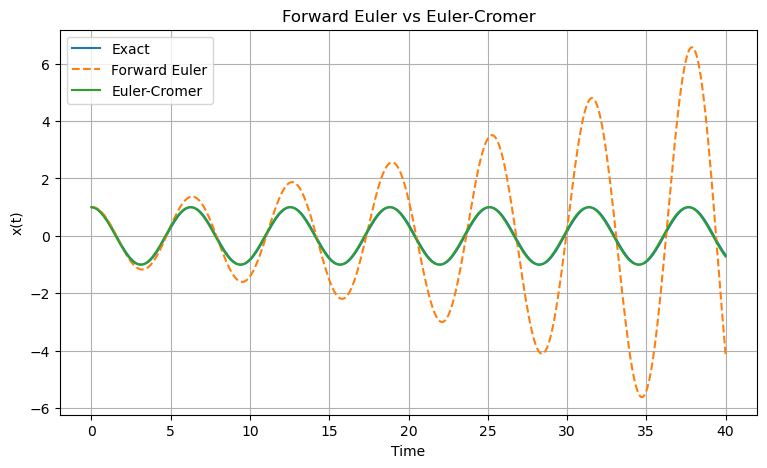

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
omega = 1.0
h = 0.1
t_final = 40

# Time array
t = np.arange(0, t_final+h, h)

# Arrays
x_fe = np.zeros(len(t))
v_fe = np.zeros(len(t))

x_ec = np.zeros(len(t))
v_ec = np.zeros(len(t))

# Initial conditions
x_fe[0] = 1.0
x_ec[0] = 1.0

v_fe[0] = 0.0
v_ec[0] = 0.0

# Forward Euler
for n in range(len(t)-1):
    a = -omega**2 * x_fe[n]
    
    v_fe[n+1] = v_fe[n] + h*a
    x_fe[n+1] = x_fe[n] + h*v_fe[n]

# Euler-Cromer
for n in range(len(t)-1):
    a = -omega**2 * x_ec[n]
    
    v_ec[n+1] = v_ec[n] + h*a
    x_ec[n+1] = x_ec[n] + h*v_ec[n+1]

# Exact solution
x_exact = np.cos(omega*t)

# Plot
plt.figure(figsize=(9,5))
plt.plot(t, x_exact, label='Exact')
plt.plot(t, x_fe, '--', label='Forward Euler')
plt.plot(t, x_ec, label='Euler-Cromer')

plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Forward Euler vs Euler-Cromer')
plt.grid(True)
plt.legend()
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.8 — Energy Behavior

For the harmonic oscillator, the total energy is

$$
E=\frac{1}{2}mv^2+\frac{1}{2}kx^2.
$$

Forward Euler tends to increase energy over time.

Euler-Cromer does not exactly conserve energy, but the energy usually oscillates around the correct value instead of drifting systematically upward.

This makes Euler-Cromer much more physically realistic for long simulations.

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">
<strong>Important Idea</strong>

A numerical method does not need to conserve energy exactly to produce good long-term behavior.

Preventing systematic energy drift is often more important.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.9 — Symplectic Integrators

Euler-Cromer is the simplest example of a **symplectic integrator**.

Symplectic methods are extremely important in:

- celestial mechanics,
- molecular dynamics,
- Hamiltonian mechanics,
- plasma physics,
- accelerator physics.

These methods are specifically designed for systems where long-term geometric structure matters.

More advanced symplectic methods include:

- Leapfrog integration,
- Velocity Verlet,
- Stormer-Verlet methods.

Euler-Cromer serves as an important introduction to this broader class of numerical algorithms.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C1.4.10 — Summary

The Euler-Cromer method updates velocity first:

$$
v_{n+1}=v_n+h a_n,
$$

then updates position using the new velocity:

$$
x_{n+1}=x_n+h v_{n+1}.
$$

Key ideas:

- it is closely related to Forward Euler,
- it is still first-order accurate,
- it behaves much better for oscillatory systems,
- it reduces artificial energy drift,
- it is a symplectic method,
- it preserves qualitative motion more effectively.

<div style="background-color:#fff8e1; border-left:6px solid #ffcc00; padding:14px; border-radius:4px;">
<strong>Big Picture</strong>

Euler-Cromer demonstrates an important lesson in computational physics:

$$
\text{numerical accuracy}
\neq
\text{physical realism}.
$$

Sometimes a method with the same formal accuracy can produce dramatically better physical behavior because it respects the underlying geometry of the system.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">